# 03 - Multilayer ANNs

**Section:** ANNs | **Prereqs:** `ANNs/ANNs.ipynb` | **Next:** `ANNs/NNClasses.ipynb`

The same qwerties classification, but with a genuinely deep stack:
`2 -> 16 -> 1 -> 1`. The interesting part is the failure mode built into that
architecture - a one-unit bottleneck between two ReLUs.

**Why depth helps.** Each `Linear` layer is a linear map; stacking two with
nothing between them collapses into a single linear map. The non-linear
activation between them is what buys you extra expressive power - without it,
a 10-layer network is exactly as powerful as a 1-layer one.

**Watch for:** the harder blob positions here (A=[1,5], B=[3,1]) plus the narrow
bottleneck make some runs land at ~50% accuracy. That is the architecture, not
a bug.

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

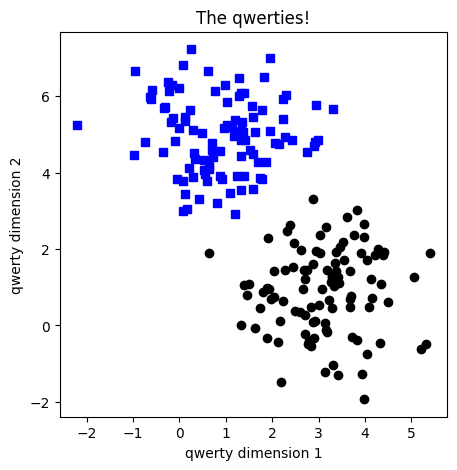

In [165]:
# Two overlapping Gaussian blobs. Compare with ANNs.ipynb: the class centres
# are closer here, so the problem is harder and depth actually has something
# to do.
nPerClust = 100
blur = 1

A = [  1, 5]
B = [  3, 1 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [147]:
# 2 -> 16 -> 1 -> 1, ReLU between layers, Sigmoid at the end.
# The width-1 layer is a bottleneck: EVERY piece of information the 16 hidden
# units extracted has to pass through a single number. Worse, it sits behind a
# ReLU, so if that unit goes negative for all inputs the network outputs a
# constant and training stalls at chance accuracy.
## Building a model

model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1),
    nn.ReLU(),
    nn.Linear(1,1),
    nn.Sigmoid()
)

model

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): ReLU()
  (4): Linear(in_features=1, out_features=1, bias=True)
  (5): Sigmoid()
)

In [148]:
# BCELoss + SGD, matching the Sigmoid output.
lossfunc = nn.BCELoss()
lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr = lr)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.05
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [149]:
# The standard loop. Full-batch here: all 200 samples in one forward pass.
# Mini-batches arrive in Regularization/Mini_batch.ipynb.
epochs = 10000
losses = torch.zeros(epochs)


for i in range(epochs):
  #forward pass

  yhat = model(data)

  loss= lossfunc(yhat, labels)
  losses[i] = loss

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

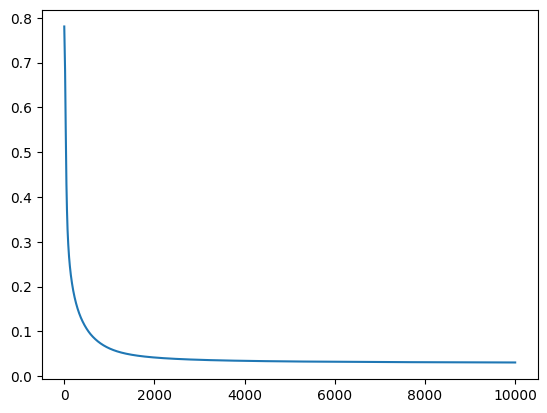

In [150]:
# Run this notebook a few times. Some curves drop smoothly; others sit flat at
# the top - those are the runs where the bottleneck unit died.
plt.plot(losses.detach());

In [163]:
# Accuracy on the SAME data the model trained on. It measures memorisation as
# much as learning - the train/test split that fixes this is in Cross Validation/.
predictions = model(data)

predlabels = predictions>.5


# find errors
misclassified = np.where(predlabels != labels)[0]

# total accuracy
totalacc = 100-100*len(misclassified)/(2*nPerClust)

print('Final accuracy: %g%%' %totalacc)
print(misclassified)



Final accuracy: 98%
[ 93 122 179 183]


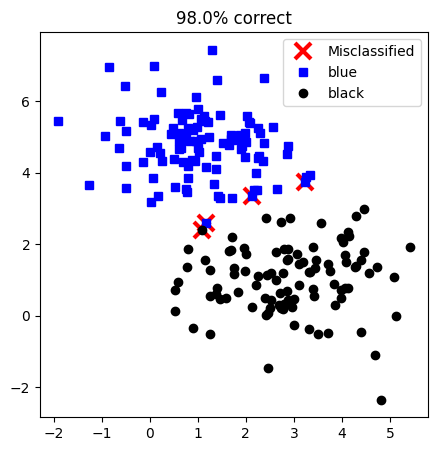

In [164]:
# Where the errors are: on the boundary between the clouds, as expected.
fig = plt.figure(figsize=(5,5))
plt.plot(data[misclassified,0] ,data[misclassified,1],'rx',markersize=12,markeredgewidth=3)
plt.plot(data[np.where(~predlabels)[0],0],data[np.where(~predlabels)[0],1],'bs')
plt.plot(data[np.where(predlabels)[0],0] ,data[np.where(predlabels)[0],1] ,'ko')

plt.legend(['Misclassified','blue','black'],bbox_to_anchor=(1,1))
plt.title(f'{totalacc}% correct')
plt.show()

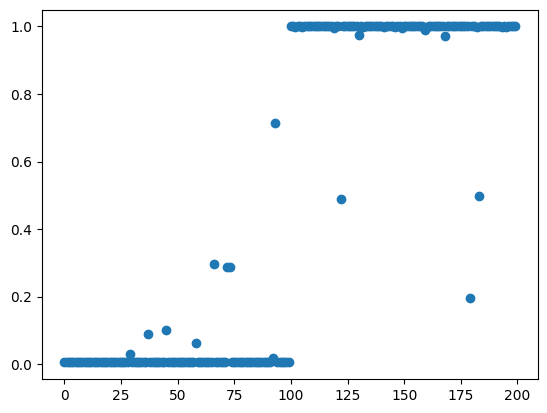

In [153]:
# Raw sigmoid outputs. Confident models push these to 0 and 1; values bunched
# around 0.5 mean the model is guessing.
plt.plot(predictions.detach(),'o');